[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CCS-ZCU/EMLAP_ETL/blob/master/scripts/emlap-tokens-explorations_colab-ready.ipynb)

This Jupyter Notebook, which can be executed both locally or using a Cloud Computing service such as Google Colab, serves to demonstrate the potential of the computationally readable & morphologically annotated version of the EMLAP corpus.

It combines two publicly data files: one for EMLAP metadata, one for the morphologically annotated token data. These two can be mapped on each other using the individual document id (`no.` attribute in the metadata table, and `id` attribute in the tokens table). As this notebook demonsrates, these two files allow to proceed with incredible diverse types of analysis without necessity to download and parse multiple files.

This representation of the data is very similar to the data model used within the GreLa database, which however offers some additional advanced and efficient database-search functionalities.

In [61]:
import pandas as pd
import requests
import nltk
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt

In [3]:
# first let's load our latest version of the metadata table
emlap_metadata = pd.read_csv("https://raw.githubusercontent.com/CCS-ZCU/EMLAP_ETL/refs/heads/master/data/emlap_metadata.csv", index_col=0, sep=";")
emlap_metadata.head(5)

,working_title,filenames,no.,is_done,is_noscemus,if_noscemus_id,AUTHORSHIP,is_one_author,#if more than 1 author skip section and choose compendium below,is_author_known,...,CONTENTS,genre,subject,SOURCE OF FILE,link,source_of_file,origin_of_copy,other_notes,tokens_N,aurhor_wd
0,"Augurello, Chrysopoeia",100001_Augurello1515_Chrysopoeia_GB_Noscemus,100001,True,True,713324.0,NaN,True,NaN,True,...,NaN,didactic poem,alchemy,NaN,https://wiki.uibk.ac.at/noscemus/Chrysopoeia,GB,Noscemus,NaN,23718,NaN
1,"Pseudo-Lull, Secretis",100002_Pseudo-Lull1518_De secretis_naturae_MDZ...,100002,True,False,NaN,NaN,True,NaN,True,...,NaN,treatise,"alchemy, medicine",NaN,https://www.digitale-sammlungen.de/en/view/bsb...,MDZ,MBS,NaN,24673,NaN
2,"Pantheus, Ars Transmutatione",100003_Pantheus1518_Ars_Transmutationis_Metall...,100003,True,False,NaN,NaN,True,NaN,True,...,NaN,treatise,alchemy,NaN,https://www.google.co.uk/books/edition/Ars_Tra...,GB,BL,NaN,8646,NaN
3,"Anon, Vera alchemiae",100004_Anon1561_Verae_Alchemiae_MDZ_MBS,100004,True,False,NaN,NaN,True,NaN,True,...,NaN,"compendium, florilegium",alchemy,NaN,https://mdz-nbn-resolving.de/details:bsb10141168,MDZ,MBS,NaN,3521,NaN
4,"Pantheus, Voarchadumia",100005_Pantheus1530_Voarchadumia_ONB,100005,True,False,NaN,NaN,True,NaN,True,...,NaN,treatise,alchemy,NaN,https://data.onb.ac.at/rep/10588E49,ONB,ONB,NaN,20386,NaN


In [28]:
len(emlap_metadata)

100

In [37]:
# build a simple dict object mapping ids on titles
# useful for overview plots below
title_date = emlap_metadata.apply(lambda row: row["working_title"] + " ({})".format(str(row["date_publication"])), axis=1)
id_to_date_dict = dict(zip(emlap_metadata["no."].astype(str), emlap_metadata["date_publication"]))
id_to_title_dict = dict(zip(emlap_metadata["no."].astype(str), title_date))
id_to_title_dict

{'100001': 'Augurello, Chrysopoeia (1515)',
 '100002': 'Pseudo-Lull, Secretis (1518)',
 '100003': 'Pantheus, Ars Transmutatione (1518)',
 '100004': 'Anon, Vera alchemiae (1561)',
 '100005': 'Pantheus, Voarchadumia (1530)',
 '100006': 'Savonarola, De arte conficiendi aquam vitae (1532)',
 '100007': 'Anon, Rosarium philosophorum (1550)',
 '100008': 'Severinus, Epistola (1571)',
 '100009': 'Vegius, Inter inferiora corpora (1518)',
 '100010': 'Bracesco, De alchimia dialogi duo (1548)',
 '100011': 'Anon, De alchemia (1541)',
 '100012': 'Gessner, Euonymus (1552)',
 '100013': 'Ulstadt, Coelum (1525)',
 '100014': 'Toxites, Spongia (1567)',
 '100015': 'Gessner, Euonymus II (1569)',
 '100016': 'Bonus, Pretiosa margarita novella (1546)',
 '100017': 'Bodenstein, Isagoge (1559)',
 '100018': 'Trevisan, Peri chemeias (1567)',
 '100019': 'Ulstadt, De epidemia (1526)',
 '100020': 'Dorn, Artificii chymistici (1569)',
 '100021': 'Dorn, Clavis (1567)',
 '100022': 'Anon, De alchimia opuscula  (1550)',
 '10

In [7]:
# now load full table of morphologically annotated tokens data table directly from the server.
# This is a complete morphological annotated version of the dataset in one file, which can be used for any sort of down stream computational text analysis.
emlap_tokens_df = pd.read_parquet("https://ccs-lab.zcu.cz/emlap_shared/emlap_tokens_df_2025-12-03.parquet")
emlap_tokens_df.shape # let's inspect its shape (N rows x N columns

(6477016, 13)

In [12]:
# a random look somewhere to get an idea of the structure
emlap_tokens_df[100000:100010]

,token_text,lemma,pos,ref,char_start,char_end,id,sent_idx,sent_len,page,textblock,tag,blocktype
100000,magni,magnus,ADJ,"{'blocktype': 'text', 'page': [4], 'tag': '', ...",88,93,100014,24,129,[4],[15],,text
100001,",",",",PUNCT,"{'blocktype': 'text', 'page': [4], 'tag': '', ...",93,94,100014,24,129,[4],[15],,text
100002,Duxisti,duco,VERB,"{'blocktype': 'text', 'page': [4], 'tag': '', ...",95,102,100014,24,129,[4],[16],,text
100003,tanto,tantus,ADV,"{'blocktype': 'text', 'page': [4], 'tag': '', ...",103,108,100014,24,129,[4],[16],,text
100004,non,non,PART,"{'blocktype': 'text', 'page': [4], 'tag': '', ...",109,112,100014,24,129,[4],[16],,text
100005,tibi,tu,PRON,"{'blocktype': 'text', 'page': [4], 'tag': '', ...",113,117,100014,24,129,[4],[16],,text
100006,turpe,turpis,ADJ,"{'blocktype': 'text', 'page': [4], 'tag': '', ...",118,123,100014,24,129,[4],[16],,text
100007,uiro,uir,NOUN,"{'blocktype': 'text', 'page': [4], 'tag': '', ...",124,128,100014,24,129,[4],[16],,text
100008,.,.,PUNCT,"{'blocktype': 'text', 'page': [4], 'tag': '', ...",128,129,100014,24,129,[4],[16],,text
100009,Nil,nihil,PRON,"{'blocktype': 'text', 'page': [4], 'tag': '', ...",0,3,100014,25,18,[4],[17],,text


Explantion of individual attributes:

Basic explantion of individual columns/attributes:
* `token_text`: the token as it appears in the text, after some basic precleaning (character normalization etc.)
* `lemma`: a dictionary-entry-like form of the token, assigned automatically within a morphological analysis pipeline (*latinCy* model for Python *spaCy* library)
* `pos` : standard part-of-speech tag,  assigned automatically  within the morphological analysis pipeline
* `ref` : additional metadata for each token, especially concerning its location within the source (see below)
* `char_start` : position of the opening character of the token within the source sentence raw text - allows to navigate to specific token while being able to disambiguate multiple occurrences of the same token within a sentence (especially useful for contextual embeddings from GreLa)
* `char_end` : position of the ending character of the token within the source sentence raw text
* `id` : numerical identifier of the work within EMLAP - can be used to obtain any additional work-level metadata without duplicating them here
* `sent_idx` : positional index of token's source sentence within the source text. Sentence division assigned automatically  within the morphological analysis pipeline. When needed, allows to render  sentence-level text.
* `sent_len` : N of characters of the source sentence.
* `page` : page index (*0-based indexing*) from which the token comes from. Typically one number, but formatted as a list for machine readiblity, since sometimes a token crosses page boundaries (via hyphen, which we removed).
* `textblock` : textblock (usually a line) index (*in 0-based indexing*) from which the token comes from. Typically one number, but formatted as a list for machine readiblity, since sometimes a token crosses textblock boundaries (via hyphen, which we removed).
* `tag` : a tag assigned manually by human annotaters during the OCR data curation.
* `blocktype` : a manually (in case of margins) or automatically (in case of titles) assigned type of the text content. Possible values are "margin", "header" or "text" (textblocks classified as "header" or "footer" were removed during the cleaning phase).


## Global overview

Here is a couple of examples how you can inspect the corpus as a whole.

In [112]:
# the easiest way to count number of tokens per workdps)
works_tokens = emlap_tokens_df.value_counts("id").reset_index()
works_tokens["title_date"] = works_tokens["id"].apply(lambda x: id_to_title_dict[x])
works_tokens["date"] = works_tokens["id"].apply(lambda x: id_to_date_dict[x])
works_tokens = works_tokens[["date", "title_date", "count"]]

/tmp/ipykernel_486836/2472139599.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(works_tokens_reversed["title_date"])


[Text(0, 0, 'Severinus, Epistola (1571)'),
 Text(0, 1, 'Phaedro, De aquila (1562)'),
 Text(0, 2, 'Toxites, Spongia (1567)'),
 Text(0, 3, 'Francus, De arte chemica (1607)'),
 Text(0, 4, 'Khunrath, Confessio (1599)'),
 Text(0, 5, 'Pantheus, Ars Transmutatione (1518)'),
 Text(0, 6, 'Fanianus, De arte metallicae (1560)'),
 Text(0, 7, 'Anon, Tractatus de secretissimo arcano (1611)'),
 Text(0, 8, 'Cephalus, Apotelesmata philosophica (1601)'),
 Text(0, 9, 'Hagecius, De cerevisia (1585)'),
 Text(0, 10, 'Drebbel, Tractatus Duo (1621)'),
 Text(0, 11, 'Paracelsus, De vita longa (1560)'),
 Text(0, 12, 'Bodenstein, Isagoge (1559)'),
 Text(0, 13, 'Savonarola, De arte conficiendi aquam vitae (1532)'),
 Text(0, 14, 'Du Chesne, Ad Iacobi Auberti (1575)'),
 Text(0, 15, 'Sendivogius, De sulphure (1616)'),
 Text(0, 16, 'Hagecius, Actio medica (1596)'),
 Text(0, 17, 'Dienheim, Medicina universalis (1610)'),
 Text(0, 18, 'Pseudo-Aquinas, De secreta alchemiae magnalia (1579)'),
 Text(0, 19, 'Albertus, De con

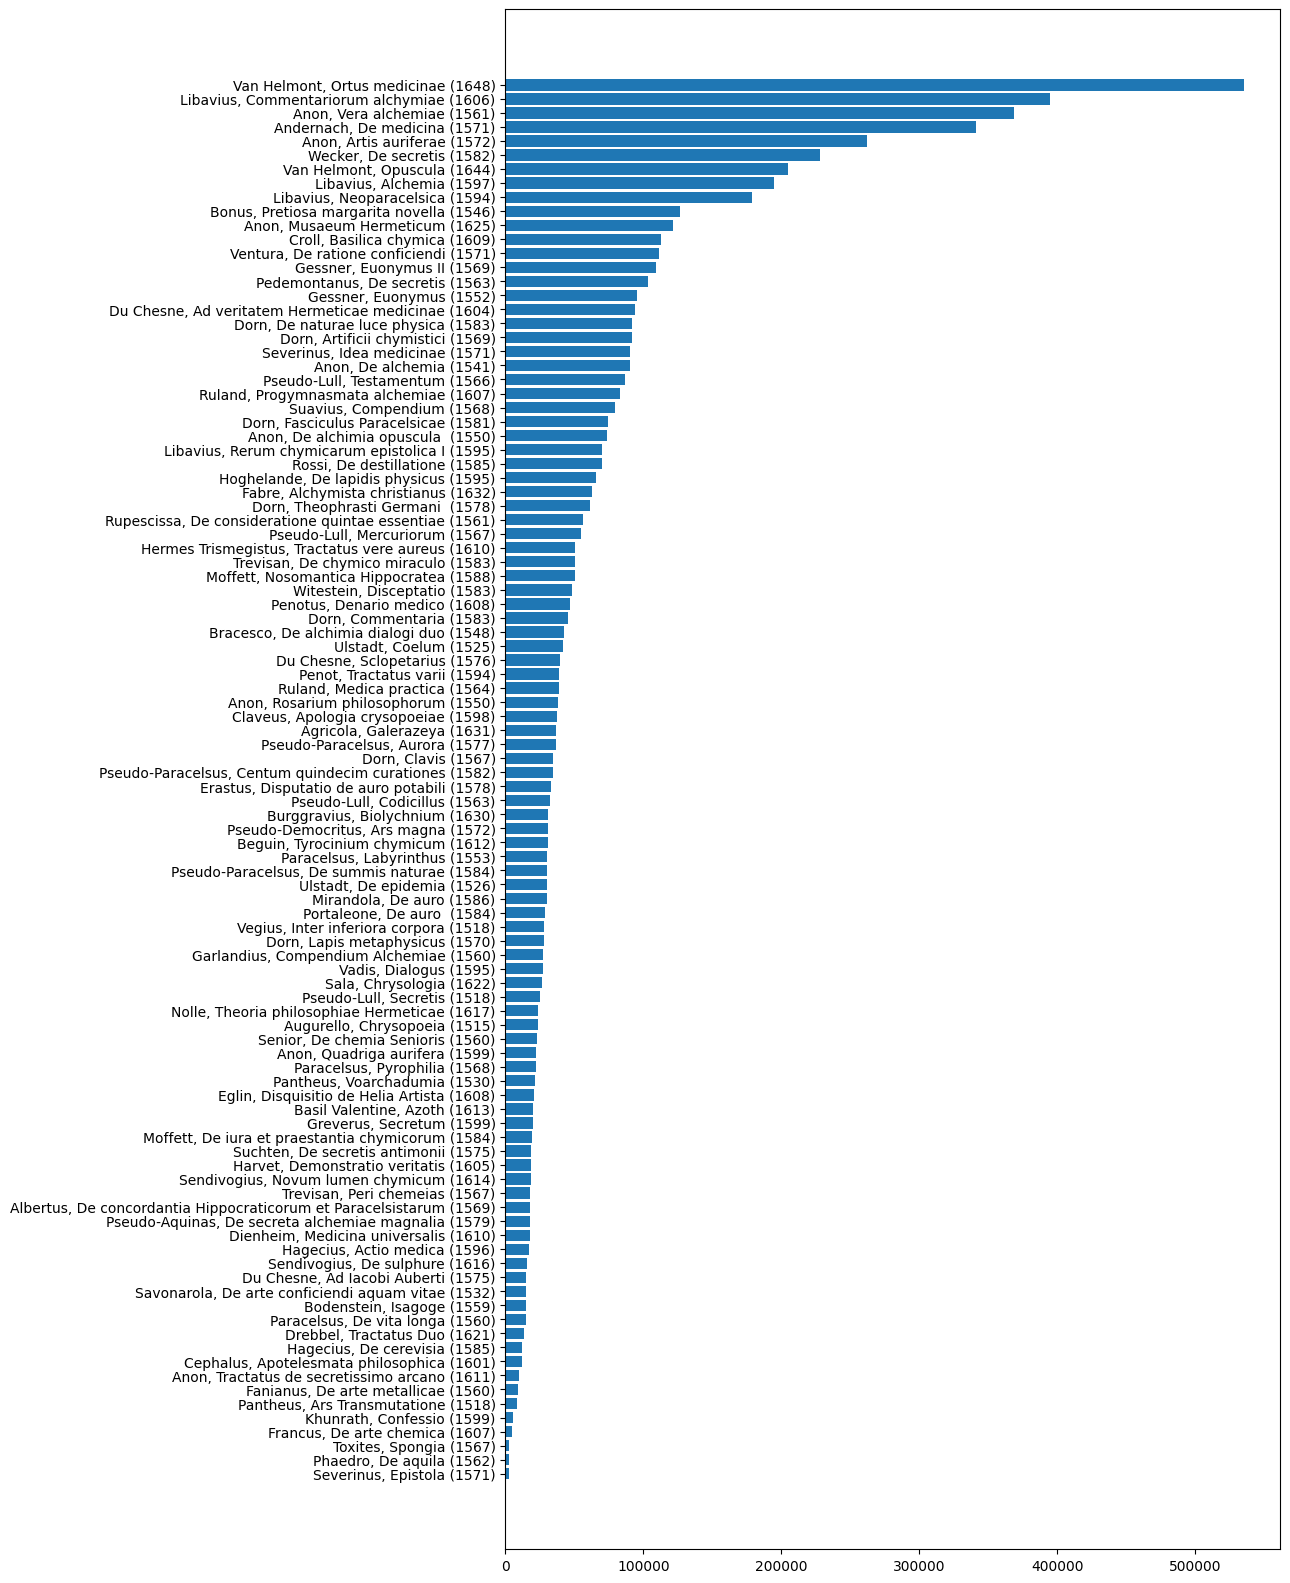

In [113]:
fig, ax = plt.subplots(1,1,figsize=(10, 20))
works_tokens_reversed = works_tokens.sort_values("count", ascending=True)
ax.barh(works_tokens_reversed["title_date"], works_tokens_reversed["count"])
ax.set_yticklabels(works_tokens_reversed["title_date"])

In [55]:
# First of all, look at the most frequent raw tokens:
# as usually, there appears to be a lot of stopwords, among the most frequent ones
emlap_tokens_df["token_text"].value_counts().head(20)

token_text
,       725929
.       339372
&       212459
in      137305
:        88214
est      75287
non      54277
ut       43471
ad       40720
quod     40217
cum      40173
per      36024
ex       35376
de       27009
uel      26013
quae     24510
a        23665
si       20855
quam     18884
sunt     18800
Name: count, dtype: int64

In [56]:
# but with this format, we can easily filter them out by focusing on a subset of postags:
emlap_tokens_df[emlap_tokens_df["pos"].isin(["NOUN", "ADJ", "VERB", "PROPN"])]["token_text"].value_counts().head(20)

token_text
aqua        14426
natura       8574
potest       7311
corpus       6482
fit          6350
ignis        6282
aquam        6045
naturae      6031
spiritus     5785
materia      5616
aurum        5343
naturam      5301
argentum     5155
igne         4782
terra        4675
aquae        4586
ignem        4490
habet        4291
fieri        4275
modo         4110
Name: count, dtype: int64

In [116]:
# we can also inspect distribution of individual POS tags.
emlap_tokens_df["pos"].value_counts()

pos
PUNCT    1434275
NOUN     1358905
VERB      915291
ADJ       489283
ADP       431607
ADV       396326
DET       330822
PRON      235866
SCONJ     204660
CCONJ     171060
AUX       157958
PROPN     141078
PART      113359
NUM        77330
SYM         8670
X           6592
INTJ        3934
Name: count, dtype: int64

In [123]:
# or we can specifically focus on tokens manually tagged as symbol, for which we introduced its own POS tag: "SYM":
emlap_tokens_df[emlap_tokens_df["pos"]=="SYM"]["lemma"].value_counts()

lemma
y          2989
recipe     1464
z          1422
lb          936
scr         288
           ... 
male          1
recipie       1
zs i          1
o             1
aster         1
Name: count, Length: 134, dtype: int64

In [124]:
# or we can specifically focus frequencies of lemmata of certain pos tags within margins
emlap_tokens_df[
        (emlap_tokens_df["blocktype"]=="margin") &
        (emlap_tokens_df["pos"].isin(["NOUN", "ADJ", "VERB", "PROPN"]))]["lemma"].value_counts()

lemma
natura         296
ars            249
capitulum      248
corpus         241
spiritus       231
              ... 
uoluntarius      1
stuffa           1
principatus      1
calesco          1
commoror         1
Name: count, Length: 10366, dtype: int64

This individual-tokens format is unsuitable for searching any sort of co-occurrences at the global level. However, this functonality can be added by rendering the tokens into some other format of text.

For instance. We can obtain the whole corpus or any part of it as one continuous string.

The most straightforward way is just to produce a list and to join it:

In [125]:
emlap_string_raw = " ".join(emlap_tokens_df["token_text"].tolist())

In [60]:
emlap_string_raw[:1000]

'Germani Paracelsi , Medicorum Et Philosophorum omnium , in uniuersum facile Principis . De restituta utriusque Medicinae uera Praxi . Liber Primus . Gerardo Dorn Doctore Physico , ac interprete Germanico , in hunc ordinem recolligente . Ad Illustriss . ac Potentiss . Prin cip . D. Francisc . Ualesium , Andegauorum , Biturigum , Alenconium , Turonensium , & c . Ducem . Alterius Non Sit Qui Suus Esse Potest Lugduni , Pro Iacobo Dv Puys . M. D. Lxxuiii . Cum priuileg . Caesareae ac Regiae maiest . ad decennium . Simum , Et Potentissimum Principem , Franciscum De Ualois Galliae filium Regium , Ducem Alenconium , & c . Tradit nobis Magnus ille Germanus Theophrastus Paracelsus , Medicae Philosophiae iamdudum consopitae , atque sepultae cum reliquis artibus , nouissimus excitator , omnem sapientiam ab uno solo patre , luminum datore Deo pendere : ac ad nos , ut ad eius filios , partim haereditario Iure , partim suae liberalitatis munere deriuare . Largitur siquidem bonus ille parens omnium ,

However, in this format the spaces between punctuation can be disturbing a bit. Let's get rid of them.

In [63]:
emlap_string_raw = re.sub(r'\s+([.,:;?!])', r'\1', emlap_string_raw)
emlap_string_raw[:1000]

'Germani Paracelsi, Medicorum Et Philosophorum omnium, in uniuersum facile Principis. De restituta utriusque Medicinae uera Praxi. Liber Primus. Gerardo Dorn Doctore Physico, ac interprete Germanico, in hunc ordinem recolligente. Ad Illustriss. ac Potentiss. Prin cip. D. Francisc. Ualesium, Andegauorum, Biturigum, Alenconium, Turonensium, & c. Ducem. Alterius Non Sit Qui Suus Esse Potest Lugduni, Pro Iacobo Dv Puys. M. D. Lxxuiii. Cum priuileg. Caesareae ac Regiae maiest. ad decennium. Simum, Et Potentissimum Principem, Franciscum De Ualois Galliae filium Regium, Ducem Alenconium, & c. Tradit nobis Magnus ille Germanus Theophrastus Paracelsus, Medicae Philosophiae iamdudum consopitae, atque sepultae cum reliquis artibus, nouissimus excitator, omnem sapientiam ab uno solo patre, luminum datore Deo pendere: ac ad nos, ut ad eius filios, partim haereditario Iure, partim suae liberalitatis munere deriuare. Largitur siquidem bonus ille parens omnium, sapientiam & artes omnibus in uniuersum 

In [68]:
# This might be use for basic multiword phrase search.
# However, with various limitations, such as different capitalization or declinations.
# For that, we still need to work with the morphologically annotated data, idaůy
emlap_string_raw.count("mercurius metallorum")

6

In [71]:
# when we first lowercase...
emlap_string_raw.lower().count("mercurius metallorum")

11

In [74]:
# for other applications, it might be useful to obtain a hybrid text consisting from a list of filtered lemmata:
emlap_lemmata_str = " ".join(emlap_tokens_df[emlap_tokens_df["pos"].isin(["NOUN", "ADJ", "VERB", "PROPN"])]["lemma"].tolist()).lower()
emlap_lemmata_str[:1000]

'germani paracelsi medicus philosophus uniuersus principis restituo medicina uerum praxum liber gherardus dorn doctor physicus interpres germanicus ordo recolligo illustriss potentiss cipe decimus francisc ualesium andegauus biturigus alenconius turonensium dux possum lugduni iacobus marcus decimus caesarea regia maisum decennium potentissimum principem franciscum ualois gallia filius regium dux alenconius trado magnus germanus theophrastus paracelsus medicus philosophia consopitus sepelio ars nouus excito sapientia pater lumen dator deus pendeo filius haereditarius ius liberalitas munus deriuo largior bonus parens sapientia ars uniuersus singulus licet experior industrius homo minimus idiota glorior praesumo membrum do corpus caeterus par cunctus animus aequum sapientia capax docilesque fio uolo iniquus homo homo disco res foelicis delitesco dormio ars uigilo facultas soporo excito do coelitus introduco insum primordium res dubius delibero conuenio eaqui singulus ignotus nodus expedio

In [75]:
# Another way to work with the data is to work at the sentence level. The tokens data trace positional indeces of source text sentences, which have to be first combined into an work id + sentence index identifier.
emlap_tokens_df["work_sent_id"] = emlap_tokens_df.apply(lambda row: str(row["id"]) + "_" + str(row["sent_idx"]), axis=1)

In [81]:
emlap_sents_df = (
    emlap_tokens_df
    .groupby("work_sent_id", sort=False)["token_text"]
    .agg(" ".join)
    .reset_index(name="sent_string")
)

In [90]:
emlap_sents_df[10000:10010]

,work_sent_id,sent_string
10000,100034_611,Hic puluis in calido ac sicco loco non in humi...
10001,100034_612,Quicunque tempore pestis magno ardore interno ...
10002,100034_613,"tunc melius habet , extinguit omnem internum c..."
10003,100034_614,"sin autem feruidus quidem tumor , ut carbuncul..."
10004,100034_615,Qui tempore pestis uel alias calore infestatur...
10005,100034_616,Hoc optimum extinguendi fundamentum est qui co...
10006,100034_617,"illi sumant huius pulueris , & cumini bene tri..."
10007,100034_618,aut 4 .
10008,100034_619,horas noctuque ac postridie faciant similiter ...
10009,100034_620,sin autem nullam primo die possint habere sede...


In [91]:
# in a similar way, you are be able to obtain lemmatized sentences etc.

## Working with individual works

All the stuff above can be further elaborated when working with individual works.

First of all, based on its id, you can easily look at tokens from a single specific work:

In [96]:
work_id = "100085"
emlap_work_tokens_df = emlap_tokens_df[emlap_tokens_df["id"]==work_id]
len(emlap_work_tokens_df)

394698

In [104]:
# you can also work with a selection of multiple works at once:
works_ids = ["100084", "100085"]
emlap_subset_tokens_df = emlap_tokens_df[emlap_tokens_df["id"].isin(works_ids)]
len(emlap_subset_tokens_df)

507241

In [109]:
# or, with a bit more coding, you can select works on some metadata from the metadata table:
# for instance, extract IDs for all works from the period between any two dates
emlap_period_ids = [str(id) for id in emlap_metadata[emlap_metadata["date_publication"].between(1551, 1560)]["no."].tolist()]
emlap_period_ids

['100012', '100017', '100023', '100024', '100026', '100029', '100041']

In [110]:
# ...and extract corresponding token rows as in the example above
emlap_subset_tokens_df = emlap_tokens_df[emlap_tokens_df["id"].isin(emlap_period_ids)]
len(emlap_subset_tokens_df)

214802

In [111]:
# and calculate, for instance frequencies of words within the period:
emlap_subset_tokens_df[emlap_subset_tokens_df["pos"].isin(["NOUN", "ADJ", "VERB", "PROPN"])]["lemma"].value_counts().head(20)

lemma
aqua        1835
facio        850
dico         747
oleum        717
ignis        682
destillo     673
corpus       657
possum       614
habeo        556
res          544
uinum        531
pars         489
lapis        462
uideo        460
natura       448
uas          448
liber        432
pono         394
terra        376
homo         376
Name: count, dtype: int64